# Lesson 145 · RelGT: five elements, one relational token

Student lab · PROVIDED / TODO / CHECK / EXIT. Three learner functions are called by the full model, temporal audit and checkpoint selector. Default execution checks a synthetic full network and saved author evidence. It does not train the nine-configuration benchmark. Author execution does not establish learner mastery.

In [ ]:
# @colab-bootstrap — pinned installs on Colab; local kernel uses its existing stack.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch==2.5.1','--index-url','https://download.pytorch.org/whl/cu124'])
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==1.26.4','pandas==2.2.3','pyarrow==18.1.0','scipy==1.14.1','scikit-learn==1.5.2','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','h5py==3.12.1','einops==0.8.0'])
    if 'torch' in sys.modules and sys.modules['torch'].__version__.split('+')[0]!='2.5.1':
        raise RuntimeError('Packages installed; restart runtime and run from the top.')
from pathlib import Path
import ast,base64,copy,hashlib,io,json,math,tempfile,types,zlib,contextlib
import numpy as np
import torch
from IPython.display import display
RUN_FULL_REPRODUCTION=False


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From contextual scores to contextual row tokens</p>
<p><strong>Reading route.</strong> Build five row descriptions → follow local and global attention → audit token ownership → interpret the reproduction boundary.</p>
<details><summary>Quick prerequisite reminder</summary><p>A token is one sampled row occurrence represented as a vector. A projection is a learned mapping to another vector space. Local attention compares tokens belonging to the same query. Global attention here reads a stored centroid memory; it does not fetch every database row at prediction time.</p></details>
</aside>
<!-- sequence-review:end -->



## Your tangible win

Trace one relational query through **RelGT**, then implement three contracts that the actual model, data audit and trainer use. You will be able to explain both what attention changes and what a successful reproduction must establish. This advances our mission: make relational-model claims defensible through visible computation and controlled evidence.



Answer the retrieval questions before proceeding.



## 1 · What the previous methods leave unresolved

[RelGNN](https://avistian.github.io/relational/lessons/0143-relgnn-reproduction.html) changes how messages travel along foreign-key paths. A foreign key identifies a row in another table. RelGNN's composite route moves information across a bridge without first collapsing every relationship into one shared state. [ContextGNN](https://avistian.github.io/relational/lessons/0144-contextgnn.html) uses a shared query graph to rank nearby candidates contextually and distant candidates through a separate item representation.

Neither mechanism asks every pair of sampled rows to exchange information directly. That is the new question here. Suppose two results belong to different races but share a driver. A graph layer normally follows the database's links. A Transformer can compare the two sampled result tokens directly. It must still know which table each row came from, when it occurred, and how it relates to the query. Otherwise an unordered bag of row attributes loses relational meaning.

> **In plain terms.** RelGT widens communication inside a sampled context, while enriching each row's representation so the context retains relational clues. Attention cannot use rows that were never sampled, and a larger communication range is not a guarantee of better predictions.

The primary reading is [Dwivedi et al., Relational Graph Transformer, §§3–4](https://arxiv.org/html/2505.10960v1). The paper evaluates entity classification and regression; it excludes recommendation tasks. We return to F1 driver-position, so Lesson 144's full-catalog sponsor ranking objective does not carry over.



## 2 · Model architecture: a row becomes five vectors

<figure class="relgt-figure" tabindex="0">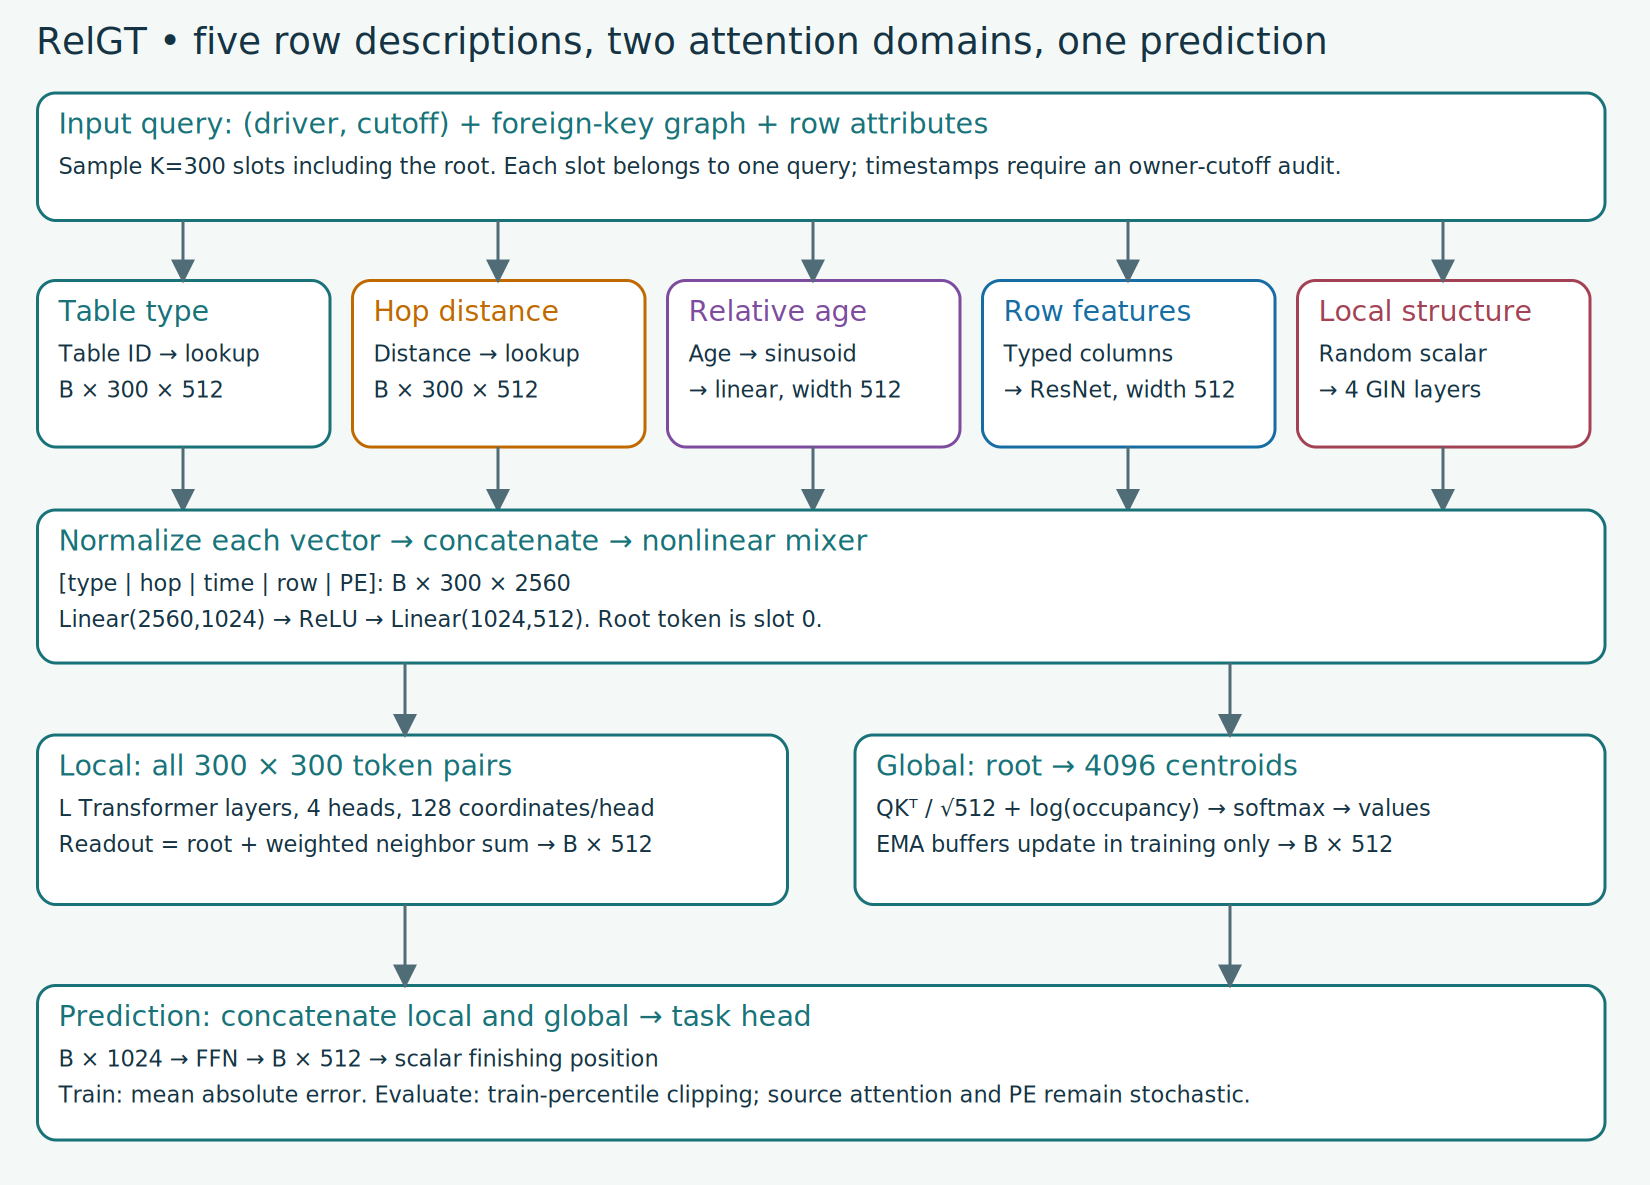<figcaption>Trace a query through five encoders, local and global attention, and the prediction head. Source variant; all dimensions shown.</figcaption></figure>

A **query** is a driver ID and prediction cutoff. The target is the mean finishing position over the next 60 days. The released pipeline first builds a heterogeneous graph: rows are nodes, table names identify node types, and foreign keys define edges. It gathers neighbors up to two hops from each root and selects a fixed context. The release uses **300 slots including the root**, rather than 300 neighbors plus a root. Sampling can repeat rows when the neighborhood is small.

**Shapes.** Let `B` be the number of queries in a batch, `K=300` the slots per query, and `d=512` the hidden width. Each of the following components produces a `B × K × d` array. One slot is one sampled row occurrence owned by one query.

1. **Table type.** A learned embedding lookup maps a table ID to a vector. An embedding is a trainable row of numbers. It distinguishes, for example, a driver from a result.
2. **Hop distance.** Another embedding represents distance from the root: zero for the root, one or two for graph neighbors. The source reserves hop three for global fallback samples; it is not a measured third-hop path.
3. **Relative time.** The release computes age in days as `(cutoff − row_time) / 86400`. Sinusoidal positional features, followed by a learned linear transformation, encode that number. Undated rows receive zero. Negative ages receive a learned mask vector. **Masking an age does not remove the row's attributes.**
4. **Row attributes.** Each table has a typed feature encoder and a four-layer residual network. Numerical, categorical and other supported columns become a common vector. A residual connection adds an earlier hidden state to a later transformation, helping information and gradients travel through the network. The release replaces nonfinite input tensor values before this encoder.
5. **Local structure.** Each sampled occurrence gets a fresh random scalar. A projection and four residual GIN layers propagate these values along sampled edges. A GIN layer combines a node's own representation with a sum of neighbor representations, then transforms it with a neural network. The resulting vector carries connectivity information that type and hop alone cannot describe.

Each component is normalized separately. **Layer normalization** rescales coordinates within a vector. The release concatenates the components in the order **type, hop, time, features, structure**, producing `5d=2560` coordinates. Its mixing network maps `2560 → 1024 → 512`, with a ReLU between the two linear layers. ReLU replaces negative values with zero.

<figure class="relgt-figure" tabindex="0">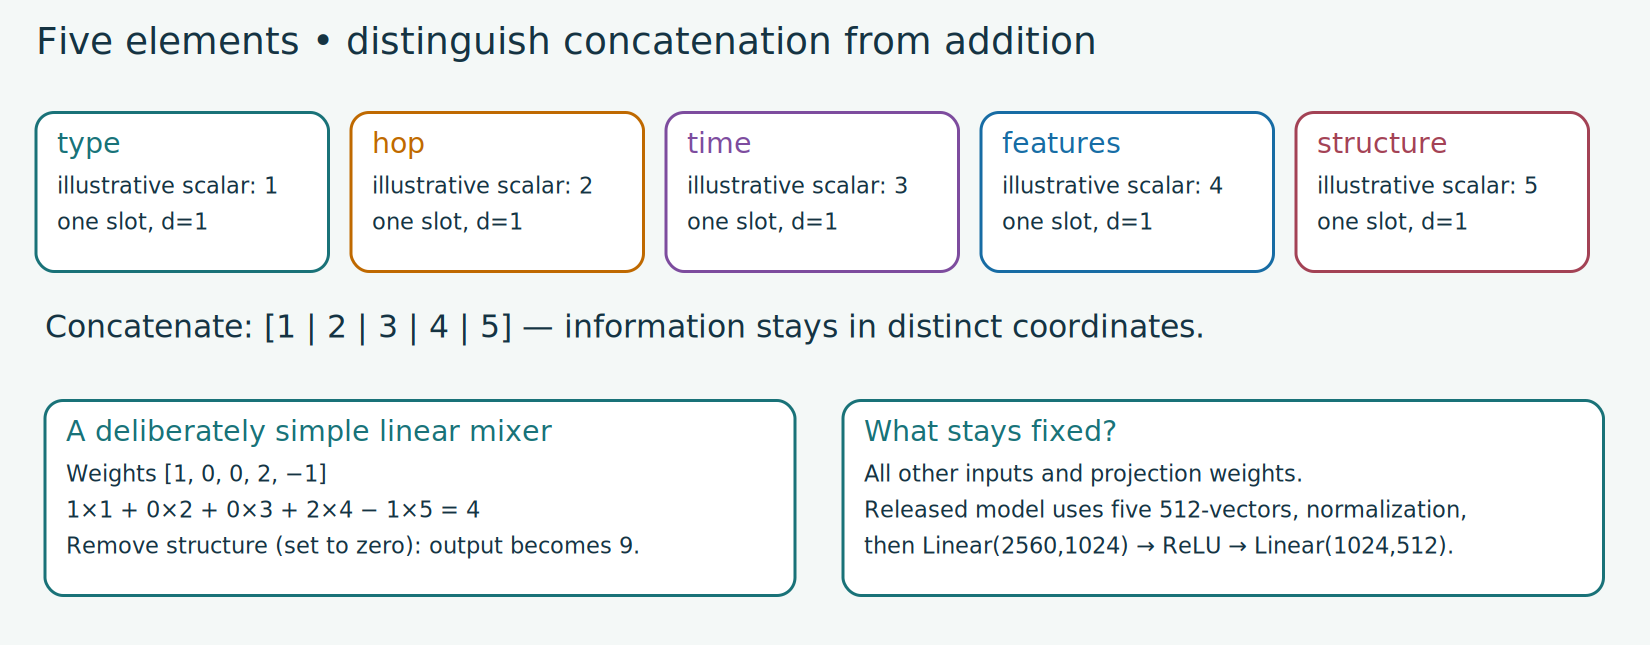<figcaption>Fixed-weight illustrative scalar projection; removing the fifth component changes 4 to 9.</figcaption></figure>

**Worked example.** Use scalar components `[1,2,3,4,5]` and weights `[1,0,0,2,−1]`. The projection is `1 + 8 − 5 = 4`. Setting only the structural component to zero changes the output to 9. Summing the five inputs first would lose which weight belongs to which component. This example isolates concatenation; it is smaller than the released nonlinear mixer.

Predict the fixed-weight projection when structure changes from 5 to 0. Then compute it.

**TODO 1 — `mix_five`.** Concatenate five equally shaped components and apply the supplied projection. Preserve gradients to every component. Your function is called inside the complete model, not only by an exercise checker.

> **Source distinction.** Paper §3 writes a linear relative-time encoder and a single token projection. The pinned release uses sinusoidal time features and a two-layer mixer. Its random structure features are resampled on every forward call, including evaluation. We expose these differences rather than implying that the equations and release are identical. [Encoder source](https://github.com/snap-stanford/relgt/blob/19e423ca3e7cac761130aba790857f2dc3a46ef7/encoders.py).



## 3 · Local attention changes who can communicate

**In plain terms.** Every slot asks which other slots in its own query context contain useful information. It does not have to traverse the FK path again at every Transformer layer.

Each local layer projects tokens into **queries, keys and values**, written `Q`, `K` and `V`. A query-key dot product measures compatibility. Dividing by the square root of the per-head width controls its scale. **Softmax** exponentiates these scores and divides by their sum, producing nonnegative weights that sum to one. The layer computes `softmax(QKᵀ / √128)V`. Four heads perform separate comparisons; each head has 128 coordinates. This use of `K` for keys is distinct from the context-size symbol.

The attention matrix has `300 × 300` entries per query and head. Different queries do not attend to one another. Residual additions, normalization and a feed-forward network complete each layer. More layers repeat that computation; the released sweep uses one, four or eight.

**Readout.** After the final normalization, the source keeps the root vector and forms a learned weighted average of the other slots. It scores each neighbor jointly with the root, normalizes those scores over neighbors, then adds the weighted neighbor vector to the root. This produces one local `B × 512` representation.

A repeated sampled row occupies multiple slots. That can change its total attention weight. Moreover, the released adjacency map keeps only the last slot for a duplicate row as an edge destination. Neither repetition nor arbitrary slot order should be described as a faithful copy of a unique-node induced graph.



## 4 · Global attention reads a training-time memory

<figure class="relgt-figure" tabindex="0">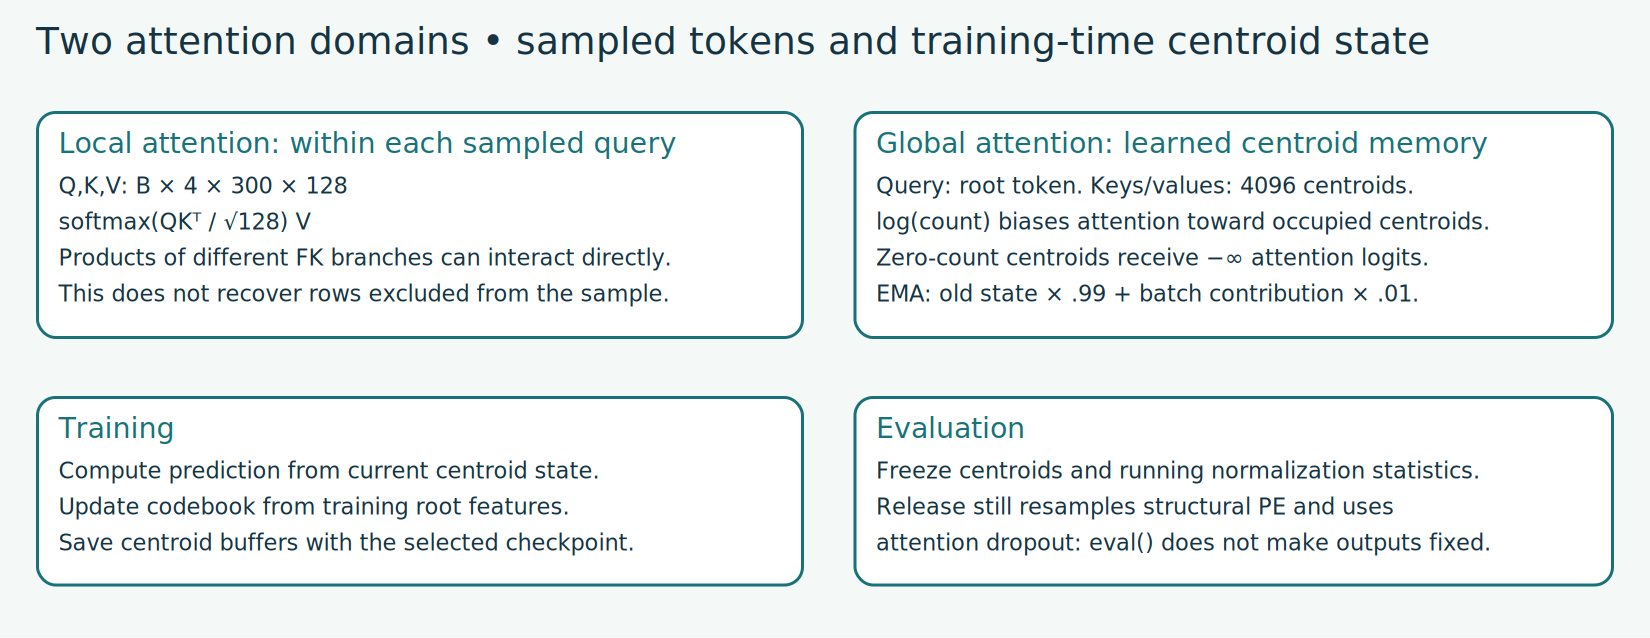<figcaption>Local all-pairs computation and global centroid state have different information and update boundaries.</figcaption></figure>

A **centroid** summarizes a cluster of root representations. RelGT stores 4,096 centroids and updates them using **exponential moving averages (EMA)**: each update retains most old state and adds a small contribution from the current training batch. The decay is 0.99. These are buffers updated by clustering, not ordinary embedding parameters trained directly by gradient descent.

The root attends to centroid keys and values. The released global branch scales scores by `√512`, and adds `log(centroid occupancy)`. Occupancy counts the assignments in its node-to-centroid buffer. A zero count gives a negative-infinite logit, removing that centroid's attention weight. This buffer is initialized randomly; it must not be presented as an exact census of historically observed database rows.

The local and global vectors are separately normalized, concatenated to `B × 1024`, and passed through a feed-forward network and scalar prediction head. Training minimizes **mean absolute error (MAE)**: the mean of `|prediction − target|`. Evaluation clips predictions to the training targets' second and ninety-eighth percentiles, following the source.

**State boundary.** Centroid updates happen during training; evaluation freezes centroid and normalization state. Save those buffers with a checkpoint. However, the released scaled-dot-product attention receives its dropout probability unconditionally. **Dropout** randomly removes contributions; it remains active in this local attention operation during evaluation. Along with resampled structural features, this means repeated predictions can differ even after `model.eval()`.



## 5 · A correct encoder cannot repair the wrong query context

Predict first: does a positive cached age prove that the row is legal for its actual query?

<figure class="relgt-figure" tabindex="0">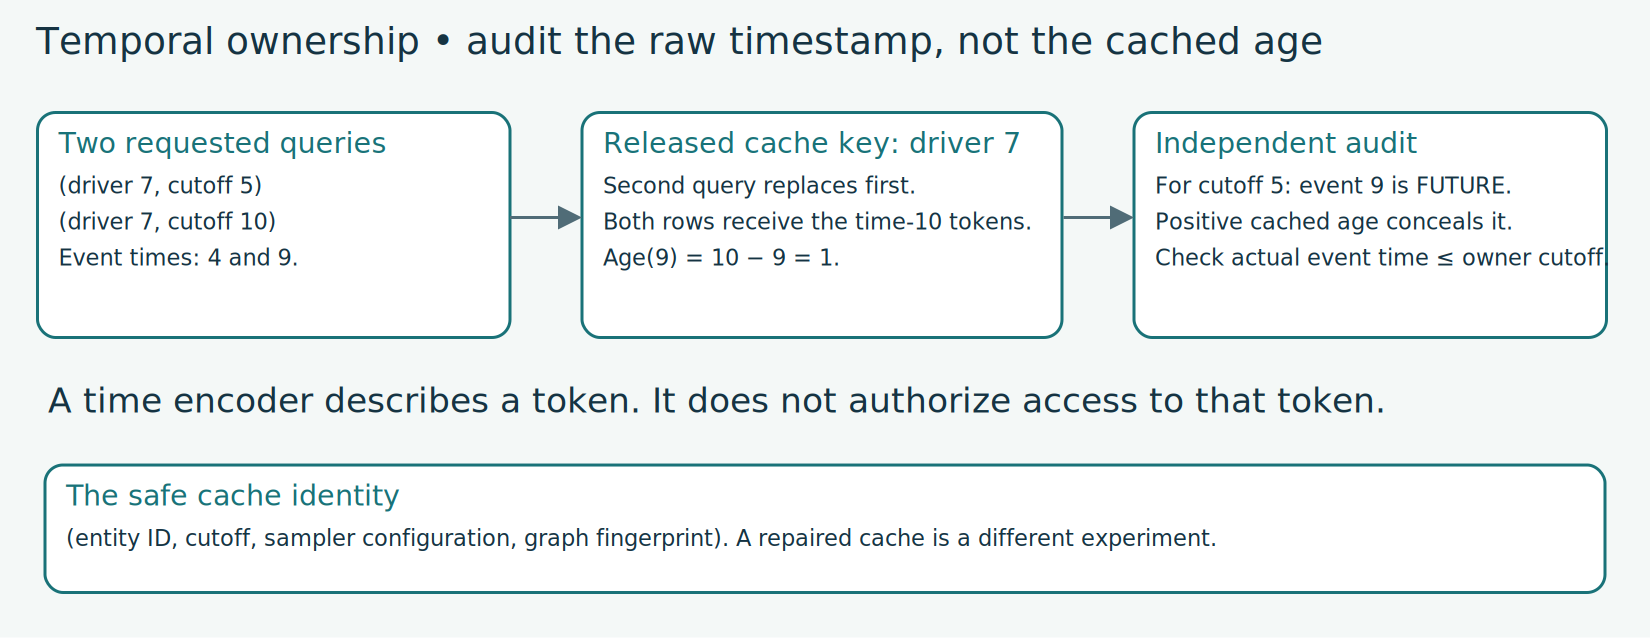<figcaption>Two queries share an entity but require different temporal contexts. A positive stored age can hide a violation.</figcaption></figure>

**Worked example.** Driver 7 has queries at times 5 and 10. An event occurs at time 9. The event is eligible for the later query but unavailable to the earlier one. If a cache stores only `driver 7 → context`, its later entry overwrites the earlier context. Both queries can then receive the time-9 event. The cached age is `10−9=1`, a positive number, even when the actual owner cutoff is 5.

The original `local_nodes_hetero` returns a dictionary keyed by node type and entity ID, omitting cutoff. Its HDF5 writer reuses that entry for every repeated entity in the chunk. This is a source behavior, not merely a hypothetical bug in our adaptation. A separate fallback branch samples globally when a root has no neighbors, without filtering the fallback rows by cutoff.

Keep event time 9 and cached age 1 fixed. Which actual cutoffs from 5 through 10 permit the event?

**TODO 2 — `audit_tokens`.** Check raw timestamps against the cutoff of their actual query row. Reject duplicate `(entity, cutoff)` keys. Return violating `(query row, token slot)` pairs. Missing timestamps remain an explicit availability limitation. Positive cached ages are insufficient evidence.

A corrected cache would use full query identity and a fingerprint of the sampler and graph. A corrected fallback would filter candidates before sampling. Those changes are scientifically useful, but they create a different pipeline. This lesson preserves the original behavior for the audit and does not pass off a repaired score as the published experiment.



## 6 · Reproduce the experiment, then defend the boundary

The named target is **RelGT v1 Table 1, `rel-f1/driver-position`**, published test MAE **3.9170**. The paper's RDL GNN comparator is **4.022**. Both are published numbers, not fresh measurements from this lesson. They correspond to a descriptive relative reduction of about 2.61%; one task does not establish general superiority. [Table 1](https://arxiv.org/html/2505.10960v1#S4).

**Held fixed:** full task population, released graph preparation provenance, width 512, 300 slots, 4,096 centroids, batch 256, Adam learning rate `0.0001`, weight decay `0.00001`, and seed 0. **Varied:** three depths `{1,4,8}` crossed with three dropout values `{0.3,0.4,0.5}`: nine configurations. Each chosen dropout value is used for both feed-forward and attention dropout. Each configuration requests 100 epochs. The release parses warmup steps but does not apply a warmup schedule in this training loop. Gradient norms are clipped to one.

**TODO 3 — `last_validation_min`.** Select the last epoch attaining the smallest validation MAE. The source uses `<=`, so `[4,3,3,5]` selects epoch 3, not epoch 2. This differs from earlier lessons' first-minimum contract. Test never chooses a checkpoint or configuration. The full runner declares its additional cross-configuration selection rule because a historical aggregation script is unavailable.

| Evidence | Training queries | Validation queries | Future token occurrences |
|---|---:|---:|---:|
| Full train token audit | 7453 | — | 569,502 |
| Full val token audit | — | 499 | 21,368 |
| Full test token audit | — | — | 0 |

**Full selected reproduction: INCOMPLETE.** The source token cache fails the temporal contract. The full test cache contains 760 queries; zero future-token violations there does not repair leaked training/validation contexts. All **8,712 labels** were independently rebuilt. Graph preprocessing is **reused under verified hashes from L143**, not freshly regenerated here.

Depth 1 timing pilot: **768 training queries**, **256 validation queries**, partial validation MAE **9.084049**. Test **NOT_RUN**. This is invalid-context source replay for timing, not benchmark evidence. Real-batch original-model maximum output difference: **1.91e-06**.

**Cost decision: STOP.** Temporal audit FAIL independently blocks clean reproduction. The three shallow 100-epoch configurations alone project USD 26.80; all nine at that same measured shallow speed project USD 80.41, before final evaluations and overhead. Deeper pilots and full fits were not dispatched. Estimates use linear batch scaling, not measured full epochs.

Historical identity **NOT_ESTABLISHED**; whole paper **NOT_RUN**; live Colab/deployment **NOT_CHECKED**; learner **PENDING_WRITTEN_DEFENSE**.


The default notebook runs a small complete-network forward/backward fixture, source parity checks, original-cache failure probes, and independent audits of saved author evidence. Its small synthetic network is mechanism evidence. The complete released-scale trainer is visible after the exercises, with a separate guarded execution gate. **Running the default notebook is not running nine full experiments.**

The US$10 total cap includes preparation, pilots, validation, failed attempts and overhead. We reserve before launching workers and retain failed attempts. If either temporal validity or remaining budget fails, the complete reproduction stays `INCOMPLETE`; the runner and evidence still ship. See the [exact protocol and commands](https://avistian.github.io/relational/labs/l145-reproduction.md).

> **Scope check.** Source parity tests software agreement. A numerically close MAE tests only a score difference. Historical reproduction additionally needs matching data, preprocessing, cache, selection and environment. No result here establishes real-world attribute availability, whole-paper reproduction, deployment behavior or learner mastery.



## Lab and exit defense

Open the [student notebook](https://avistian.github.io/relational/labs/0145-relational-graph-transformer.ipynb), [executed solution](https://avistian.github.io/relational/labs/solutions/0145-relational-graph-transformer.ipynb), or [prepared notebook HTML](https://avistian.github.io/relational/labs/html/0145-relational-graph-transformer.html). Use the [one-page reference](https://avistian.github.io/relational/reference/relgt.html) after attempting retrieval.

1. Complete all three TODOs and run their CHECK cells. Explain why each contract lies on a real execution path.
2. Trace one `B × 300 × 512` token array through local readout, global attention and the head. Distinguish EMA buffers from gradient-trained parameters.
3. Explain the cache overwrite with actual timestamps. Propose a repair and state why its result needs a new experiment label.
4. Defend the reproduction verdict using the complete schedule, temporal audit and cost ledger. Identify which evidence was executed by the author and which work you personally completed.

Write your explanation before checking the reference solution. Send it to the teaching agent for feedback.

**Spaced return.** Tomorrow, reconstruct the five components without notes. In one week, explain why `eval()` and a positive age do not each prove what their names might suggest. Ask the teaching agent to review your code, tensor trace and written defense; follow-up questions are part of this lesson.


<!-- sequence-next:start -->
**Carry this forward.** Use the access and selection audits in Lesson 146. A GNN–transformer comparison is meaningful only after specifying what each model saw and how its result was chosen. [Continue to Lesson 146](https://avistian.github.io/relational/lessons/0146-gnn-vs-graph-transformer.html).
<!-- sequence-next:end -->


In [ ]:
# PROVIDED: pinned source and saved author evidence, not current learner results.
SOURCE_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_ROOT=Path('sources/l145').resolve();SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,text in SOURCE_FILES.items():(SOURCE_ROOT/name).write_text(text)
AUTHOR_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
AUTHOR_AUDIT={'graph': {'graph_sha256': '6c72c684d51aaedbba11946d9babee705a7c0bc1e93415f4d48926b38973da99', 'checkpoint_sha256': '3ba2b6e5c99bc0939d13debb6b06d8d0f0828148361662d54bab83f6c23943df', 'checkpoint_revision': '321e6f6e7af5d7546b637f147783fc28ab5d4a7a', 'preprocessing': 'FRESH full released snapshot; seed42; pinned GloVe', 'archives': {'db.zip': 'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482', 'tasks/driver-position.zip': '775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}, 'source_checks': {'graph': True, 'nn': True, 'utils': True}, 'rows': {'circuits': 77, 'constructor_results': 9408, 'constructor_standings': 10170, 'constructors': 211, 'drivers': 857, 'qualifying': 4082, 'races': 820, 'results': 20323, 'standings': 28115}, 'fk_edges': 169421, 'edges': 338842, 'routes': [['dim-fact-dim', 'constructor_results', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'constructor_results'], ['dim-fact-dim', 'constructor_results', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'constructor_results'], ['dim-fact-dim', 'constructor_standings', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'constructor_standings'], ['dim-fact-dim', 'constructor_standings', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'constructor_standings'], ['dim-fact-dim', 'qualifying', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_driverId', 'drivers', 'constructors', 'rev_f2p_constructorId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'qualifying'], ['dim-fact-dim', 'qualifying', 'f2p_constructorId', 'constructors', 'drivers', 'rev_f2p_driverId', 'qualifying'], ['dim-dim', 'races', 'f2p_circuitId', 'circuits'], ['dim-dim', 'circuits', 'rev_f2p_circuitId', 'races'], ['dim-fact-dim', 'results', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'results'], ['dim-fact-dim', 'results', 'f2p_raceId', 'races', 'constructors', 'rev_f2p_constructorId', 'results'], ['dim-fact-dim', 'results', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'results'], ['dim-fact-dim', 'results', 'f2p_driverId', 'drivers', 'constructors', 'rev_f2p_constructorId', 'results'], ['dim-fact-dim', 'results', 'f2p_constructorId', 'constructors', 'races', 'rev_f2p_raceId', 'results'], ['dim-fact-dim', 'results', 'f2p_constructorId', 'constructors', 'drivers', 'rev_f2p_driverId', 'results'], ['dim-fact-dim', 'standings', 'f2p_raceId', 'races', 'drivers', 'rev_f2p_driverId', 'standings'], ['dim-fact-dim', 'standings', 'f2p_driverId', 'drivers', 'races', 'rev_f2p_raceId', 'standings']], 'packages': {'torch': '2.5.1+cu124', 'torch-geometric': '2.6.1', 'pytorch-frame': '0.2.3', 'relbench': '1.1.0', 'numpy': '1.26.4', 'pandas': '2.2.3', 'sentence-transformers': '3.3.1', 'pyg-lib': '0.4.0+pt25cu124'}}, 'graph_provenance': 'REUSED hash-verified L143 materialization; not fresh preprocessing', 'split_audits': {'train': {'queries': 7453, 'unique_entities': 771, 'overwritten_queries': 6682, 'future_token_occurrences': 569502, 'affected_queries': 3277, 'examples': [{'row': 4, 'key': [52, 1063065600], 'slot': 8, 'type': 'standings', 'entity': 25683, 'actual_time': 1064707200, 'cached_age': -79.0}, {'row': 4, 'key': [52, 1063065600], 'slot': 10, 'type': 'constructor_results', 'entity': 8952, 'actual_time': 1183291200, 'cached_age': -1451.5}, {'row': 4, 'key': [52, 1063065600], 'slot': 26, 'type': 'results', 'entity': 18169, 'actual_time': 1082851200, 'cached_age': -289.0}, {'row': 4, 'key': [52, 1063065600], 'slot': 28, 'type': 'qualifying', 'entity': 3902, 'actual_time': 1247313600, 'cached_age': -2192.5}, {'row': 4, 'key': [52, 1063065600], 'slot': 33, 'type': 'standings', 'entity': 27005, 'actual_time': 1174186800, 'cached_age': -1346.125}, {'row': 4, 'key': [52, 1063065600], 'slot': 44, 'type': 'qualifying', 'entity': 3848, 'actual_time': 1243080000, 'cached_age': -2143.5}, {'row': 4, 'key': [52, 1063065600], 'slot': 57, 'type': 'constructor_results', 'entity': 9267, 'actual_time': 1240124400, 'cached_age': -2109.291748046875}, {'row': 4, 'key': [52, 1063065600], 'slot': 62, 'type': 'results', 'entity': 18834, 'actual_time': 1129471200, 'cached_age': -828.5833129882812}, {'row': 4, 'key': [52, 1063065600], 'slot': 86, 'type': 'standings', 'entity': 28060, 'actual_time': 1254632400, 'cached_age': -2277.208251953125}, {'row': 4, 'key': [52, 1063065600], 'slot': 93, 'type': 'standings', 'entity': 26777, 'actual_time': 1151848800, 'cached_age': -1087.5833740234375}, {'row': 4, 'key': [52, 1063065600], 'slot': 109, 'type': 'results', 'entity': 18674, 'actual_time': 1121004000, 'cached_age': -730.5833129882812}, {'row': 4, 'key': [52, 1063065600], 'slot': 114, 'type': 'constructor_standings', 'entity': 9242, 'actual_time': 1111330800, 'cached_age': -618.625}], 'cache_sha256': 'd6de7ed12fa6e080741afabf9bbc55d26bfe04c9a8b91c1ad0b0af8f818fd369'}, 'val': {'queries': 499, 'unique_entities': 47, 'overwritten_queries': 452, 'future_token_occurrences': 21368, 'affected_queries': 217, 'examples': [{'row': 1, 'key': [11, 1244505600], 'slot': 39, 'type': 'qualifying', 'entity': 4068, 'actual_time': 1256986800, 'cached_age': -624.4583129882812}, {'row': 1, 'key': [11, 1244505600], 'slot': 79, 'type': 'standings', 'entity': 27897, 'actual_time': 1245585600, 'cached_age': -492.5}, {'row': 1, 'key': [11, 1244505600], 'slot': 267, 'type': 'standings', 'entity': 28075, 'actual_time': 1255881600, 'cached_age': -611.6666870117188}, {'row': 6, 'key': [1, 1234137600], 'slot': 3, 'type': 'races', 'entity': 804, 'actual_time': 1238922000, 'cached_age': 184.625}, {'row': 6, 'key': [1, 1234137600], 'slot': 17, 'type': 'results', 'entity': 20113, 'actual_time': 1244376000, 'cached_age': 121.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 32, 'type': 'qualifying', 'entity': 3988, 'actual_time': 1252756800, 'cached_age': 24.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 39, 'type': 'standings', 'entity': 27958, 'actual_time': 1251028800, 'cached_age': 44.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 65, 'type': 'races', 'entity': 817, 'actual_time': 1254632400, 'cached_age': 2.7916667461395264}, {'row': 6, 'key': [1, 1234137600], 'slot': 73, 'type': 'standings', 'entity': 27814, 'actual_time': 1240747200, 'cached_age': 163.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 76, 'type': 'standings', 'entity': 27981, 'actual_time': 1251633600, 'cached_age': 37.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 77, 'type': 'results', 'entity': 20202, 'actual_time': 1251028800, 'cached_age': 44.5}, {'row': 6, 'key': [1, 1234137600], 'slot': 79, 'type': 'results', 'entity': 20152, 'actual_time': 1247400000, 'cached_age': 86.5}], 'cache_sha256': 'e289a5ea2a16765a778ff0c0c154fbdcd505621b38eb36339912c60ea2d4d934'}, 'test': {'queries': 760, 'unique_entities': 56, 'overwritten_queries': 704, 'future_token_occurrences': 0, 'affected_queries': 0, 'examples': [], 'cache_sha256': 'bb720d9b8db8388227c0dc9a007715d17da51b780fe45be4b9a7c63b818948a6'}}, 'independently_rebuilt_labels': 8712, 'source_revision': '19e423ca3e7cac761130aba790857f2dc3a46ef7', 'pythonhashseed': '0', 'temporal_status': 'FAIL'}
AUTHOR_PILOTS=[{'status': 'PARTIAL_TIMING_PILOT', 'layers': 1, 'dropout': 0.3, 'seed': 0, 'epochs': 1, 'history': [{'epoch': 1, 'queries': 768, 'steps': 3, 'train_seconds': 36.53126185399999, 'val_seconds': 15.257283015999995, 'val_mae': 9.084049479166666}], 'scores': {'val': 9.084049479166666}, 'test': 'NOT_RUN', 'best_epoch': 1, 'first_batch_nonfinite_gradients': {}, 'real_batch_original_max_error': 1.911073923110962e-06, 'seconds': 61.13367508299999, 'checkpoint_sha256': 'f414afe68d65ff8483a4cba389bb4ac6de2e8c7acace11ddf38c6fd555935e18', 'parameter_count': 12204294, 'scope': 'Released token-cache defects preserved; not a temporally valid benchmark reproduction'}]

## TODO · Preserve five separate elements

**Goal:** implement `mix_five`. **Why:** this contract lies on the model/audit/trainer path. **Hint boundary:** Join the last dimensions, keeping the source order and gradient flow.

In [ ]:
def mix_five(parts,projection):
    raise NotImplementedError("TODO: mix_five")

In [ ]:
def check_mix(fn):
    parts=[torch.full((2,3,2),float(i)) for i in range(5)]
    layer=torch.nn.Linear(10,2,bias=False)
    with torch.no_grad():layer.weight.copy_(torch.arange(20).reshape(2,10))
    expected=torch.tensor([130.,330.]).expand(2,3,2)
    assert torch.equal(fn(parts,layer),expected)
    x=[p.clone().requires_grad_() for p in parts];fn(x,layer).sum().backward()
    assert all(p.grad is not None and p.grad.abs().sum()>0 for p in x)
    try:fn(parts[:4],layer)
    except ValueError:pass
    else:raise AssertionError('Missing token element accepted')
check_mix(mix_five)
print("PASS: mix_five")

## TODO · Retain query ownership

**Goal:** implement `audit_tokens`. **Why:** this contract lies on the model/audit/trainer path. **Hint boundary:** Use actual timestamps and each query cutoff; never trust only the cached age.

In [ ]:
def audit_tokens(keys,timestamps):
    raise NotImplementedError("TODO: audit_tokens")

In [ ]:
def check_audit(fn):
    keys=[(7,5),(7,10)]
    assert fn(keys,[[4,5],[6,10]])==[]
    assert fn(keys,[[4,6],[6,10]])==[(0,1)]
    try:fn([(7,5),(7,5)],[[4],[4]])
    except ValueError:pass
    else:raise AssertionError('Duplicate query keys accepted')
check_audit(audit_tokens)
print("PASS: audit_tokens")

## TODO · Preserve the released tie rule

**Goal:** implement `last_validation_min`. **Why:** this contract lies on the model/audit/trainer path. **Hint boundary:** Reject invalid histories and let a tied minimum replace the earlier epoch.

In [ ]:
def last_validation_min(scores):
    raise NotImplementedError("TODO: last_validation_min")

In [ ]:
def check_selection(fn):
    assert fn([4.,3.,3.,5.])==2
    assert fn([2.,3.])==0
    for bad in [[],[1.,float('nan')]]:
        try:fn(bad)
        except ValueError:pass
        else:raise AssertionError('Invalid score history accepted')
check_selection(last_validation_min)
print("PASS: last_validation_min")

In [ ]:
# PROVIDED: independently keyed metric
def keyed_mae(keys,targets,pred_keys,predictions):
    import numpy as np
    if len(set(keys))!=len(keys) or len(set(pred_keys))!=len(pred_keys) or set(keys)!=set(pred_keys):
        raise ValueError('Prediction query identity mismatch')
    if len(targets)!=len(keys) or len(predictions)!=len(pred_keys):raise ValueError('Length mismatch')
    lookup=dict(zip(pred_keys,predictions));p=np.array([lookup[k] for k in keys]);y=np.asarray(targets)
    if not np.isfinite(p).all() or not np.isfinite(y).all():raise ValueError('Nonfinite metric')
    return float(np.abs(p-y).mean())

## PROVIDED · complete released model

Read the typed encoders, stochastic structure computation, attention and centroid update. Only tensor/graph/column primitives are imported. These MIT-licensed source-adapted classes remain visible; the five-element mixer calls your live function.

In [ ]:
# Source-adapted RelGT, MIT license in sources/l145/LICENSE.
# Pinned revision 19e423ca3e7cac761130aba790857f2dc3a46ef7.




In [ ]:
# ---- codebook.py ----
from re import X
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F


class VectorQuantizerEMA(nn.Module):
    """
    Vector Quantizer with Exponential Moving Average (EMA) for the codebook.
    Adapted from https://github.com/devnkong/GOAT

    Args:
        num_embeddings (int): The number of embeddings in the codebook.
        embedding_dim (int): The dimensionality of each embedding.
        decay (float, optional): The decay rate for the EMA. Defaults to 0.99.

    Attributes:
        _embedding_dim (int): The dimensionality of each embedding.
        _num_embeddings (int): The number of embeddings in the codebook.
        _decay (float): The decay rate for the EMA.
        _embedding (nn.Embedding): The embedding matrix.
        _ema_cluster_size (torch.Tensor): The exponential moving average of the cluster sizes.
        _ema_w (torch.Tensor): The exponential moving average of the embedding updates.
    """

    def __init__(self, num_embeddings, embedding_dim, decay=0.99):
        super(VectorQuantizerEMA, self).__init__()

        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings

        self.register_buffer(
            "_embedding", torch.randn(self._num_embeddings, self._embedding_dim)
        )
        self.register_buffer(
            "_embedding_output",
            torch.randn(self._num_embeddings, self._embedding_dim),
        )
        self.register_buffer("_ema_cluster_size", torch.zeros(num_embeddings))
        self.register_buffer(
            "_ema_w", torch.randn(self._num_embeddings, self._embedding_dim)
        )

        self._decay = decay
        self.bn = torch.nn.BatchNorm1d(self._embedding_dim, affine=False)

    def reset_parameters(self):
        nn.init.normal_(self._embedding, mean=0.0, std=1.0)
        nn.init.normal_(self._embedding_output, mean=0.0, std=1.0)
        nn.init.zeros_(self._ema_cluster_size)
        nn.init.normal_(self._ema_w, mean=0.0, std=1.0)

        self.bn.reset_parameters()

    def get_k(self):
        """
        Returns the key tensor of the embedding matrix.
        """
        return self._embedding_output

    def get_v(self):
        """
        Returns the value tensor of the embedding matrix.
        """
        return self._embedding_output[:, : self._embedding_dim]

    def update(self, x):
        inputs_normalized = self.bn(x)
        embedding_normalized = self._embedding

        # Calculate distances
        distances = (
            torch.sum(inputs_normalized**2, dim=1, keepdim=True)
            + torch.sum(embedding_normalized**2, dim=1)
            - 2 * torch.matmul(inputs_normalized, embedding_normalized.t())
        )

        # Encoding
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(
            encoding_indices.shape[0], self._num_embeddings, device=x.device
        )
        encodings.scatter_(1, encoding_indices, 1)

        # Use EMA to update the embedding vectors
        if self.training:
            self._ema_cluster_size.data = self._ema_cluster_size * self._decay + (
                1 - self._decay
            ) * torch.sum(encodings, 0)

            # Laplace smoothing of the cluster size
            n = torch.sum(self._ema_cluster_size.data)
            self._ema_cluster_size.data = (
                (self._ema_cluster_size + 1e-5) / (n + self._num_embeddings * 1e-5) * n
            )

            dw = torch.matmul(encodings.t(), inputs_normalized)
            self._ema_w.data = self._ema_w * self._decay + (1 - self._decay) * dw
            self._embedding.data = self._ema_w / self._ema_cluster_size.unsqueeze(1)

            running_std = torch.sqrt(self.bn.running_var + 1e-5).unsqueeze(dim=0)
            running_mean = self.bn.running_mean.unsqueeze(dim=0)
            self._embedding_output.data = self._embedding * running_std + running_mean

        return encoding_indices




In [ ]:
# ---- encoders.py ----
from typing import Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_frame

import torch_geometric.transforms as T
from torch_geometric.data import Data

# ------------------- Encoder classes -------------------- #

class NeighborNodeTypeEncoder(nn.Module):
    """
    Encoder for neighbor types.
    Uses an embedding layer to convert integer type indices into dense vectors.
    """
    def __init__(self, node_type_map, embedding_dim):
        """
        Args:
            node_type_map (dict): A mapping from node type strings to integer indices.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborNodeTypeEncoder, self).__init__()
        # Determine the number of unique types from the mapping
        num_types = max(node_type_map.values()) + 1
        self.embedding = nn.Embedding(num_embeddings=num_types + 1, embedding_dim=embedding_dim)
    
    def reset_parameters(self):
        self.embedding.reset_parameters() 
    
    def forward(self, type_indices):
        """
        Args:
            type_indices (Tensor): Tensor of shape (...), containing integer indices for neighbor types.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        return self.embedding(type_indices)


class NeighborHopEncoder(nn.Module):
    """
    Encoder for hop distances.
    Uses an embedding layer to convert hop counts into dense vectors.
    """
    def __init__(self, max_neighbor_hop, embedding_dim):
        """
        Args:
            max_neighbor_hop (int): The maximum hop distance in your data.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborHopEncoder, self).__init__()
        # +1 because we assume hops start from 0 or 1 and go to max_neighbor_hop inclusive
        self.embedding = nn.Embedding(num_embeddings=max_neighbor_hop + 2, embedding_dim=embedding_dim)
        
    def reset_parameters(self):
        self.embedding.reset_parameters()
    
    def forward(self, hop_distances):
        """
        Args:
            hop_distances (Tensor): Tensor of shape (...), containing integer hop distances.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        shifted = hop_distances + 1
        return self.embedding(shifted)

from torch_geometric.nn import PositionalEncoding

class NeighborTimeEncoder(nn.Module):
    """
    Two-stage time encoder using positional encoding followed by a linear layer.
    """
    def __init__(self, embedding_dim):
        """
        Args:
            embedding_dim (int): Dimension of the output embedding.
        """
        super(NeighborTimeEncoder, self).__init__()
        self.pos_encoder = PositionalEncoding(embedding_dim)
        self.linear = nn.Linear(embedding_dim, embedding_dim)
        self.mask_vector = nn.Parameter(torch.zeros(embedding_dim))
        
    def reset_parameters(self):
        self.linear.reset_parameters()
        nn.init.normal_(self.mask_vector, mean=0.0, std=0.02)

    def forward(self, rel_time):
        """
        Args:
            rel_time (Tensor): Tensor of shape [B, K] containing time values in seconds.
        Returns:
            Tensor: Encoded time features with shape [B, K, embedding_dim].
        """
        # Get the original batch dimensions
        B, K = rel_time.shape

        # Flatten the input from [B, K] to [B*K]
        flattened_time = rel_time.view(-1)

        # Apply positional encoding to the flattened input
        pos_encoded = self.pos_encoder(flattened_time)  # shape: [B*K, embedding_dim]

        # Apply a linear transformation
        linear_out = self.linear(pos_encoded)  # shape: [B*K, embedding_dim]
        linear_out = linear_out.view(B, K, -1)
        
        # create a mask: 1 where time is masked (i.e. < 0), else 0.
        mask = (rel_time < 0).unsqueeze(-1).float()
        mask_vector = self.mask_vector.unsqueeze(0).unsqueeze(0).expand(B, K, -1)
        # where mask==1, use mask_vector; else use linear_out.
        out = (1 - mask) * linear_out + mask * mask_vector
        return out
    
    
from torch_frame.nn.models import ResNet  # Ensure torch_frame is installed and imported correctly
from typing import Dict, Any

    
class NeighborTfsEncoder(nn.Module):
    """
    Encoder for neighbor TorchFrame objects.
    
    Processes a batch of lists of TorchFrame objects using a two-stage encoding style,
    similar to HeteroEncoder, for a single node type context.
    """
    def __init__(
        self,
        channels: int,
        node_type_map,  # Mapping from node type to index (if needed externally)
        col_names_dict,
        col_stats_dict,
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        """
        Args:
            channels (int): Output channels for the encoder.
            node_type_map: Mapping from node type to index.
            col_names_dict (dict): Dictionary mapping column types to list of column names.
            col_stats_dict (dict): Dictionary of statistics for columns.
            torch_frame_model_cls: Class for the TorchFrame model (default: ResNet).
            torch_frame_model_kwargs (dict): Keyword arguments for the model class.
            default_stype_encoder_cls_kwargs (dict): Dictionary mapping stype to a tuple of 
                                                      (encoder class, kwargs) for that stype.
        """
        super(NeighborTfsEncoder, self).__init__()

        self.node_type_map = node_type_map
        self.inv_node_type_map = {idx: nt for nt, idx in node_type_map.items()}
        self.encoders = nn.ModuleDict()
        self.channels = channels

        # Initialize encoders for each node type using provided dictionaries
        for node_type, stype_dict in col_names_dict.items():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](**default_stype_encoder_cls_kwargs[stype][1])
                for stype in stype_dict.keys()
                if stype in default_stype_encoder_cls_kwargs
            }
            self.encoders[node_type] = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=col_stats_dict[node_type],
                col_names_dict=stype_dict,
                stype_encoder_dict=stype_encoder_dict,
            )

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(self, batch_dict, neighbor_types):
        """
    Args:
        batch_dict (dict): A dictionary containing:
          - grouped_tfs[t_int]: A single concatenated TorchFrame of all neighbors 
                                for node type 't_int' in the batch.
          - grouped_indices[t_int]: The list of flat indices corresponding to 
                                   each row in grouped_tfs[t_int].
          - flat_batch_idx (List[int]): The batch index 'i' for each flattened neighbor.
          - flat_nbr_idx (List[int]): The neighbor index 'j' for each flattened neighbor.
        neighbor_types (Tensor): A [B, K] tensor specifying the node type indices
                                 for each neighbor in the original (batch, neighbor) shape.

    This method performs a single-pass encoding for each node type by:
      1) Encoding the concatenated TorchFrame (big_tf) for that type in one shot.
      2) Scattering the resulting embeddings back to the flattened positions.
      3) Reassembling the final [B, K, channels] tensor using 'flat_batch_idx' and 'flat_nbr_idx'.

    Returns:
        Tensor: A [B, K, channels] tensor of encoded neighbor features, preserving
                the original ordering of neighbors per sample.
    """
        grouped_tfs = batch_dict["grouped_tfs"]
        grouped_indices = batch_dict["grouped_indices"]
        flat_batch_idx = batch_dict["flat_batch_idx"]
        flat_nbr_idx   = batch_dict["flat_nbr_idx"]

        B, K = neighbor_types.shape
        N = len(flat_batch_idx)  # total flattened neighbors
        device = neighbor_types.device

        # Pre-allocate an [N, channels] buffer 
        # (Even if N==0, this works fine: shape is [0, channels].)
        encoded_flat_tensor = torch.zeros((N, self.channels), device=device)

        # 1) Encode in one shot per node type
        for t_int, big_tf in grouped_tfs.items():
            node_type_str = self.inv_node_type_map[t_int]
            encoder = self.encoders[node_type_str]

            big_tf = big_tf.to(device=device)
            
            for stype, tensor in big_tf.feat_dict.items():
                if isinstance(tensor, torch.Tensor):
                    big_tf.feat_dict[stype] = torch.nan_to_num(
                        tensor, nan=0.0, posinf=1e6, neginf=-1e6
                    )
            
            # assert torch.isfinite(big_tf.feat_dict[torch_frame.numerical]).all(), f"NaN/Inf in the raw big_tf for {node_type_str}?"
            
            out_t = encoder(big_tf)  # shape: [num_rows, channels] or [num_rows, 1, channels]
            if out_t.dim() == 3 and out_t.shape[1] == 1:
                out_t = out_t.squeeze(1)  # => [num_rows, channels]

            # Insert each row into encoded_flat_tensor
            idx_list = grouped_indices[t_int]
            idx_tensor = torch.tensor(idx_list, dtype=torch.long, device=device)
            encoded_flat_tensor[idx_tensor] = out_t

        # 2) Scatter [N, channels] -> [B, K, channels]
        output = torch.zeros((B, K, self.channels), device=device)
        
        indices_i = torch.tensor(flat_batch_idx, dtype=torch.long, device=device)
        indices_j = torch.tensor(flat_nbr_idx,   dtype=torch.long, device=device)
        output[indices_i, indices_j] = encoded_flat_tensor

        return output
    
    
from torch_geometric.nn import GINConv

class GNNPEEncoder(nn.Module):
    """
    A GNN-based positional encoder that:
      1) Assigns each node a random scalar feature from a Normal(0,1).
      2) Linearly projects it to embedding_dim.
      3) Runs a small GIN GNN on (x, edge_index, batch).
      4) Aggregates the intermediate outputs of the GNN using one of:
        - "none": use only the final layer's output,
        - "cat": concatenate all layer outputs,
        - "mean": average all layer outputs,
        - "max": max pool across all layer outputs.
      5) Returns a [B, K, embedding_dim] shaped embedding to match the rest of the pipeline.
    """
    def __init__(self, embedding_dim: int, num_layers: int = 4, pooling: str = 'none', pe_dim: int = 0):
        super().__init__()
        self.pooling = pooling.lower()
        self.num_layers = num_layers
        self.layer_embedding_dim = embedding_dim // 4
        self.pe_dim = pe_dim
        
        if self.pe_dim > 0:
            self.input_proj = nn.Linear(self.pe_dim, self.layer_embedding_dim)
        else:
           self.input_proj = nn.Linear(1, self.layer_embedding_dim)

        self.conv = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(self.layer_embedding_dim, self.layer_embedding_dim*2),
                nn.BatchNorm1d(self.layer_embedding_dim*2),
                nn.ReLU(),
                nn.Linear(self.layer_embedding_dim*2, self.layer_embedding_dim)
            )
            self.conv.append(GINConv(mlp, train_eps=True))
        
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.bns.append(nn.BatchNorm1d(self.layer_embedding_dim))
        
        if self.pooling == 'cat':
            final_input_dim = self.layer_embedding_dim * num_layers
        elif self.pooling in ['none', 'mean', 'max']:
            final_input_dim = self.layer_embedding_dim
        else:
            raise ValueError("Invalid pooling method. Choose from 'none', 'cat', 'mean', 'max'.")
        
        self.final_transform = nn.Linear(final_input_dim, embedding_dim)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        if self.input_proj.bias is not None:
            nn.init.zeros_(self.input_proj.bias)

        for conv in self.conv:
            for layer in conv.nn:
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
        
        nn.init.xavier_uniform_(self.final_transform.weight)
        if self.final_transform.bias is not None:
            nn.init.zeros_(self.final_transform.bias)

    def forward(self, edge_index, batch):
        """
        Args:
            edge_index (torch.Tensor): shape [2, E], the adjacency for the subgraph(s).
            batch (torch.Tensor): shape [total_nodes], specifying subgraph membership for each node.

        Returns:
            (torch.Tensor): shape [B, K, embedding_dim], a node-level embedding for each node
                            in the subgraph, where B is the batch size, K is the # of nodes in
                            each subgraph if each subgraph is the same size, or sum(K_i) if variable.
        """
        device = edge_index.device
        total_nodes = batch.size(0) 

        if self.pe_dim > 0:
            data = Data(edge_index=edge_index, num_nodes=total_nodes)
            transform = T.AddLaplacianEigenvectorPE(k=self.pe_dim)
            data = transform(data)
            x_input = data.laplacian_eigenvector_pe.to(device)
        else:
            x_input = torch.randn(total_nodes, 1, device=device)
            
        x = self.input_proj(x_input)
        
        outputs = []
        for i, conv in enumerate(self.conv):
            x_res = x  
            x_new = conv(x, edge_index)
            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x = x_new + x_res
            outputs.append(x)
        
        if self.pooling == 'none':
            x_final = outputs[-1]
        elif self.pooling == 'cat':
            x_final = torch.cat(outputs, dim=-1)
        elif self.pooling == 'mean':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.mean(outputs_tensor, dim=-1)
        elif self.pooling == 'max':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.max(outputs_tensor, dim=-1)[0]

        x = self.final_transform(x_final)
        
        B = batch.max().item() + 1 
        K = total_nodes // B
        out = x.view(B, K, -1)

        return out




In [ ]:
# ---- local_module.py ----
import torch
import math
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class LocalModule(nn.Module):
    def __init__(
        self,
        seq_len,
        input_dim,
        node_only_readout=False,
        n_layers=1,
        num_heads=8,
        hidden_dim=64,
        dropout_rate=0.3,
        attention_dropout_rate=0,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.node_only_readout = node_only_readout
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.ffn_dim = 2 * hidden_dim
        self.num_heads = num_heads

        self.n_layers = n_layers

        self.dropout_rate = dropout_rate
        self.attention_dropout_rate = attention_dropout_rate

        self.att_embeddings_nope = nn.Linear(self.input_dim, self.hidden_dim)

        encoders = [
            EncoderLayer(
                self.hidden_dim,
                self.ffn_dim,
                self.dropout_rate,
                self.attention_dropout_rate,
                self.num_heads,
            )
            for _ in range(self.n_layers)
        ]
        self.layers = nn.ModuleList(encoders)
        self.final_ln = nn.LayerNorm(hidden_dim)

        self.attn_layer = nn.Linear(2 * hidden_dim, 1)
        
    def reset_parameters(self):
        self.att_embeddings_nope.reset_parameters()
        self.attn_layer.reset_parameters()
        self.final_ln.reset_parameters()
        for layer in self.layers:
            layer.reset_parameters()

    def forward(self, batched_data, pretrain_token=False):
        tensor = self.att_embeddings_nope(batched_data)

        # transformer encoder
        for enc_layer in self.layers:
            tensor = enc_layer(tensor)

        output = self.final_ln(tensor)
        
        if pretrain_token:
            return output

        _target = output[:, 0, :].unsqueeze(1).repeat(1, self.seq_len - 1, 1)
        split_tensor = torch.split(output, [1, self.seq_len - 1], dim=1)

        node_tensor = split_tensor[0]
        _neighbor_tensor = split_tensor[1]

        if self.node_only_readout:
            indices = torch.arange(1, self.seq_len, 1)
            neighbor_tensor = _neighbor_tensor[:, indices]
            target = _target[:, indices]
        else:
            target = _target
            neighbor_tensor = _neighbor_tensor

        layer_atten = self.attn_layer(torch.cat((target, neighbor_tensor), dim=2))
        layer_atten = F.softmax(layer_atten, dim=1)

        neighbor_tensor = neighbor_tensor * layer_atten
        neighbor_tensor = torch.sum(neighbor_tensor, dim=1, keepdim=True)

        output = (node_tensor + neighbor_tensor).squeeze()

        return output


class FeedForwardNetwork(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate):
        super(FeedForwardNetwork, self).__init__()

        self.bn_in = nn.BatchNorm1d(hidden_size)
        self.bn_out = nn.BatchNorm1d(hidden_size)

        self.ffn_net = nn.Sequential(
            nn.Linear(hidden_size, ffn_size),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(ffn_size, hidden_size),
            nn.Dropout(dropout_rate)
        )
        
    def reset_parameters(self):
        for layer in self.ffn_net:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.bn_in(x)
        x = x.permute(0, 2, 1)
        
        x = self.ffn_net(x)
        
        x = x.permute(0, 2, 1)
        x = self.bn_out(x)
        x = x.permute(0, 2, 1)
        
        return x

class EncoderLayer(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate, attention_dropout_rate, num_heads):
        super(EncoderLayer, self).__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.attention_dropout_rate = attention_dropout_rate

        self.self_attention_norm = nn.LayerNorm(hidden_size)
        
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        
        self.self_attention_dropout = nn.Dropout(dropout_rate)
        
        self.ffn_norm = nn.LayerNorm(hidden_size)
        self.ffn = FeedForwardNetwork(hidden_size, ffn_size, dropout_rate)

    def reset_parameters(self):
        self.self_attention_norm.reset_parameters()
        
        for proj in [self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(proj.weight)
            if proj.bias is not None:
                nn.init.zeros_(proj.bias)
        self.ffn_norm.reset_parameters()
        self.ffn.reset_parameters()

    def forward(self, x, attn_bias=None):
        # self-attention block with flash attention 
        residual = x
        x_norm = self.self_attention_norm(x)  # [B, L, D]
        
        Q = self.q_proj(x_norm)  # [B, L, D]
        K = self.k_proj(x_norm)
        V = self.v_proj(x_norm)
        B, L, D = Q.shape
        head_dim = D // self.num_heads
        
        # reshape Q, K, V to shape [B, num_heads, L, head_dim].
        Q = Q.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        
        # PyTorch’s fast scaled dot-product attention (flash attention).
        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_bias,
            dropout_p=self.attention_dropout_rate,
            is_causal=False  
        )  # Returns [B, num_heads, L, head_dim]
        
        # reshape back to [B, L, D].
        attn_output = attn_output.transpose(1, 2).reshape(B, L, D)
        
        attn_output = self.out_proj(attn_output)
        attn_output = self.self_attention_dropout(attn_output)
        
        x = residual + attn_output
        
        # Feed-forward block 
        residual = x
        x_norm = self.ffn_norm(x)
        ffn_output = self.ffn(x_norm)
        x = residual + ffn_output
        return x




In [ ]:
# ---- model.py ----
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn import MLP

from einops import rearrange

from torch_frame.data.stats import StatType
from typing import Dict, Any, List


class RelGTLayer(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        local_num_layers,
        global_dim,
        num_nodes,
        heads=1,
        concat=True,
        ff_dropout=0.0,
        attn_dropout=0.0,
        edge_dim=None,
        conv_type="local",
        num_centroids=None,
        sample_node_len=100,
        **kwargs,
    ):
        super(RelGTLayer, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.local_num_layers = local_num_layers
        self.heads = heads
        self.concat = concat
        self.ff_dropout = ff_dropout
        self.attn_dropout = attn_dropout
        self.edge_dim = edge_dim
        self.conv_type = conv_type
        self.num_centroids = num_centroids
        self._alpha = None
        self.sample_node_len = sample_node_len

        self.local_module = LocalModule(
            seq_len=self.sample_node_len,
            input_dim=in_channels,
            n_layers=local_num_layers,
            num_heads=heads,
            hidden_dim=out_channels,
            dropout_rate=ff_dropout,
            attention_dropout_rate=attn_dropout
        )
        self.layer_norm_local = nn.LayerNorm(out_channels)

        if self.conv_type != "local":
            self.vq = VectorQuantizerEMA(num_centroids, global_dim, decay=0.99)
            c = torch.randint(0, num_centroids, (num_nodes,), dtype=torch.long)
            self.register_buffer("c_idx", c)
            self.attn_fn = F.softmax

            attn_channels = out_channels // heads

            self.lin_proj_g = Linear(in_channels, global_dim)
            self.lin_key_g = Linear(global_dim, heads * attn_channels)
            self.lin_query_g = Linear(global_dim, heads * attn_channels)
            self.lin_value_g = Linear(global_dim, heads * attn_channels)
            self.layer_norm_global = nn.LayerNorm(out_channels)

        self.reset_parameters()
        
    def reset_parameters(self):
        # Reinitialize global attention layers
        if self.conv_type != "local":
            self.lin_proj_g.reset_parameters()
            self.lin_key_g.reset_parameters()
            self.lin_query_g.reset_parameters()
            self.lin_value_g.reset_parameters()
            if hasattr(self, 'vq'):
                self.vq.reset_parameters()
                
        # Reinitialize LocalModule
        if hasattr(self.local_module, 'reset_parameters'):
            self.local_module.reset_parameters()
            
    def forward(self, x_set, x, node_indices):
        if self.conv_type == "local":
            out = self.local_forward(x_set)
            out = self.layer_norm_local(out)

        elif self.conv_type == "global":
            out = self.global_forward(x, node_indices)
            out = self.layer_norm_global(out)

        elif self.conv_type == "full":
            out_local = self.local_forward(x_set)
            out_global = self.global_forward(x, node_indices)
            out_local = self.layer_norm_local(out_local)
            out_global = self.layer_norm_global(out_global)
            out = torch.cat([out_local, out_global], dim=1)

        else:
            raise NotImplementedError

        return out

    def global_forward(self, x, batch_idx):
        d, h = self.out_channels, self.heads
        scale = 1.0 / math.sqrt(d)

        q_x = self.lin_proj_g(x)

        k_buf = self.vq.get_k()
        k_x = k_buf.detach().clone()
        v_buf = self.vq.get_v()
        v_x = v_buf.detach().clone()


        q = self.lin_query_g(q_x)
        k = self.lin_key_g(k_x)
        v = self.lin_value_g(v_x)

        q, k, v = map(lambda t: rearrange(t, "n (h d) -> h n d", h=h), (q, k, v))
        dots = torch.einsum("h i d, h j d -> h i j", q, k) * scale

        c, c_count = self.c_idx.unique(return_counts=True)

        centroid_count = torch.zeros(self.num_centroids, dtype=torch.long).to(x.device)
        centroid_count[c.to(torch.long)] = c_count

        dots = dots + torch.log(centroid_count.view(1, 1, -1))

        attn = self.attn_fn(dots, dim=-1)
        attn = F.dropout(attn, p=self.attn_dropout, training=self.training)

        out = torch.einsum("h i j, h j d -> h i d", attn, v)
        out = rearrange(out, "h n d -> n (h d)")

        # Update the centroids
        if self.training:
            x_idx = self.vq.update(q_x)
            self.c_idx[batch_idx] = x_idx.squeeze().to(torch.long)

        return out

    def local_forward(self, x_set, pretrain_token=False):
        return self.local_module(x_set, pretrain_token)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}({self.in_channels}, "
            f"{self.out_channels}, heads={self.heads}, "
            f"local_num_layers={self.local_num_layers})"
        )


class RelGT(torch.nn.Module):
    def __init__(
        self,
        num_nodes: int,
        max_neighbor_hop: int,
        node_type_map: Dict[str, int],
        col_names_dict: Dict[str, Dict[str, List[str]]],
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        local_num_layers: int,
        channels: int,
        out_channels: int,
        global_dim: int,
        heads: int = 4,
        ff_dropout: float = 0.0,
        attn_dropout: float = 0.0,
        conv_type: str = "full",
        ablate : str = "none",
        gnn_pe_dim : int = 0,
        num_centroids: int = 4096,
        sample_node_len: int = 100,
        args: Any = None,
    ):
        super(RelGT, self).__init__()

        self.max_neighbor_hop = max_neighbor_hop
        self.node_type_map = node_type_map
        num_node_types = len(node_type_map) + 1 # extra element for mask token
        num_hop_types = self.max_neighbor_hop + 1 # extra element for mask token
        
        self.type_encoder = NeighborNodeTypeEncoder(embedding_dim=channels, node_type_map=self.node_type_map)
        self.hop_encoder = NeighborHopEncoder(embedding_dim=channels, max_neighbor_hop=self.max_neighbor_hop)
        self.time_encoder = NeighborTimeEncoder(embedding_dim=channels)
        self.tfs_encoder = NeighborTfsEncoder(channels=channels, node_type_map=self.node_type_map, col_names_dict=col_names_dict, col_stats_dict=col_stats_dict)
        self.pe_encoder = GNNPEEncoder(embedding_dim=channels, pe_dim = gnn_pe_dim)

        self.layer_norm_type = nn.LayerNorm(channels)
        self.layer_norm_hop = nn.LayerNorm(channels)
        self.layer_norm_time = nn.LayerNorm(channels)
        self.layer_norm_tfs = nn.LayerNorm(channels)
        self.layer_norm_pe = nn.LayerNorm(channels)
        
        hidden_channels = channels

        ablate_key_dict = {
            "type" : 0,
            "hop" : 1,
            "time" : 2,
            "tfs" : 3,
            "gnn" : 4
        }
        self.ablate_idx = ablate_key_dict.get(ablate, None)
        channel_mult = 5 if self.ablate_idx is None else 4

        self.in_mixture = nn.Sequential(
            nn.Linear(channel_mult*channels, 2*channels),
            nn.ReLU(),
            nn.Linear(2*channels, channels)
        )
        
        self.convs = torch.nn.ModuleList()
        self.ffs = torch.nn.ModuleList()

        _overall_num_layers = 1
        for _ in range(_overall_num_layers):
            self.convs.append(
                RelGTLayer(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    local_num_layers=local_num_layers,
                    global_dim=global_dim,
                    num_nodes=num_nodes,
                    heads=heads,
                    ff_dropout=ff_dropout,
                    attn_dropout=attn_dropout,
                    conv_type=conv_type,
                    num_centroids=num_centroids,
                    sample_node_len=sample_node_len,
                )
            )
            h_times = 2 if conv_type == "full" else 1

            self.ffs.append(
                nn.Sequential(
                    nn.BatchNorm1d(hidden_channels * h_times), # BN in
                    nn.Linear(h_times * hidden_channels, hidden_channels * 2),
                    nn.GELU(),
                    nn.Dropout(ff_dropout),
                    nn.Linear(hidden_channels * 2, hidden_channels),
                    nn.Dropout(ff_dropout),
                    nn.BatchNorm1d(hidden_channels), # BN out
                )
            )

        # supervised task head
        self.head = MLP(
            channels,
            hidden_channels=channels,
            out_channels=out_channels,
            num_layers=2,
        )

    def reset_parameters(self):
        self.type_encoder.reset_parameters()
        self.hop_encoder.reset_parameters()
        self.time_encoder.reset_parameters()
        self.tfs_encoder.reset_parameters()
        self.pe_encoder.reset_parameters()

        for layer in self.in_mixture:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

        for conv in self.convs:
            conv.reset_parameters()
        for ff in self.ffs:
            if hasattr(ff, 'reset_parameters'):
                ff.reset_parameters()

        self.head.reset_parameters()

    def forward(self, 
                neighbor_types,
                node_indices,
                neighbor_hops,
                neighbor_times,
                grouped_tf_dict,
                edge_index=None,
                batch=None,
                ):
        
        neighbor_tfs = self.layer_norm_tfs(self.tfs_encoder(grouped_tf_dict, neighbor_types))
        neighbor_types = self.layer_norm_type(self.type_encoder(neighbor_types.long()))
        neighbor_hops = self.layer_norm_hop(self.hop_encoder(neighbor_hops.long()))
        neighbor_times = self.layer_norm_time(self.time_encoder(neighbor_times.float()))
        neighbor_subgraph_pe = self.layer_norm_pe(self.pe_encoder(edge_index, batch))
        
        cat_list = [neighbor_types, neighbor_hops, neighbor_times, neighbor_tfs, neighbor_subgraph_pe]
        if self.ablate_idx is not None:
            cat_list.pop(self.ablate_idx)
        x_set = mix_five(cat_list, self.in_mixture) if self.ablate_idx is None else self.in_mixture(torch.cat(cat_list, dim=-1))
        
        x = x_set[:, 0, :] # select seed token representation
        for i, conv in enumerate(self.convs):
            x_set = conv(x_set, x, node_indices)
            x_set = self.ffs[i](x_set)
        x_set = self.head(x_set)

        return x_set

    def global_forward(self, x, pos_enc, node_indices):
        raise NotImplementedError
        x = self.fc_in(x)
        for i, conv in enumerate(self.convs):
            x = conv.global_forward(x, pos_enc, node_indices)
            x = self.ffs[i](x)
        x = self.fc_out(x)
        return x


## CHECK · source parity and original failure probes

The fixture uses width16, K3 and eight centroids to test the full computation cheaply. It is a synthetic mechanism test, not a downscaled benchmark result. Stochastic draws are aligned for the original-model comparison.

In [ ]:
"""Independent source comparisons and reproducible release-defect probes."""
import contextlib,sys,types,copy,json
from pathlib import Path
import torch

@contextlib.contextmanager
def original_modules(root):
    names=['codebook','encoders','local_module','model'];old={n:sys.modules.get(n) for n in names}
    try:
        for n in names:
            m=types.ModuleType(n);sys.modules[n]=m;exec(compile((Path(root)/(n+'.py')).read_text(),n,'exec'),m.__dict__)
        yield sys.modules['model'].RelGT
    finally:
        for n,m in old.items():
            if m is None:sys.modules.pop(n,None)
            else:sys.modules[n]=m

def mechanism_check(source_root,visible_namespace=None):
    import numpy as np,pandas as pd,torch_frame
    from torch_geometric.data import HeteroData
    if visible_namespace is None:visible_namespace=globals()
    Visible=visible_namespace['RelGT'];torch.manual_seed(145);torch.set_num_threads(1)
    frame=torch_frame.data.Dataset(pd.DataFrame({'x':[1.,2.,3.,4.,5.,6.]}),col_to_stype={'x':torch_frame.numerical});frame.materialize()
    kw=dict(num_nodes=6,max_neighbor_hop=3,node_type_map={'row':0},col_names_dict={'row':frame.tensor_frame.col_names_dict},col_stats_dict={'row':frame.col_stats},local_num_layers=1,channels=16,out_channels=1,global_dim=8,heads=4,ff_dropout=.3,attn_dropout=.3,conv_type='full',num_centroids=8,sample_node_len=3)
    grouped={'grouped_tfs':{0:frame.tensor_frame},'grouped_indices':{0:list(range(6))},'flat_batch_idx':[0,0,0,1,1,1],'flat_nbr_idx':[0,1,2,0,1,2]}
    args=(torch.zeros(2,3,dtype=torch.long),torch.tensor([0,3]),torch.tensor([[0,1,2],[0,1,2]]),torch.tensor([[0.,2.,3.],[0.,1.,4.]]),grouped)
    extra={'edge_index':torch.tensor([[0,1,1,2,3,4,4,5],[1,0,2,1,4,3,5,4]]),'batch':torch.tensor([0,0,0,1,1,1])}
    with original_modules(source_root) as Original:
        a=Visible(**kw);b=Original(**kw);b.load_state_dict(a.state_dict())
        torch.manual_seed(77);pa=a(*copy.deepcopy(args),**extra);pa.square().sum().backward()
        torch.manual_seed(77);pb=b(*copy.deepcopy(args),**extra);pb.square().sum().backward()
        torch.testing.assert_close(pa,pb,rtol=1e-6,atol=1e-6);grads=0
        for (na,va),(nb,vb) in zip(a.named_parameters(),b.named_parameters()):
            assert na==nb
            if va.grad is not None:torch.testing.assert_close(va.grad,vb.grad,atol=1e-6,rtol=1e-6,equal_nan=True);grads+=1
        layer=sys.modules['local_module'].EncoderLayer(16,32,.3,.3,4).eval();x=torch.randn(2,3,16)
        p1=layer(x);p2=layer(x);dropout_difference=float((p1-p2).abs().max().detach());assert dropout_difference>0
        # Eval must not update global centroid state even though dropout and PE are random.
        a.eval();state={k:v.clone() for k,v in a.state_dict().items()};a(*copy.deepcopy(args),**extra)
        assert all(torch.equal(v,a.state_dict()[k]) for k,v in state.items())
    # Execute original local_nodes_hetero, replacing multiprocessing only.
    m=types.ModuleType('l145_original_utils');exec(compile((Path(source_root)/'utils.py').read_text().replace('from sentence_transformers import SentenceTransformer',''),'utils.py','exec'),m.__dict__)
    class SerialPool:
        def __init__(self,processes,initializer,initargs):initializer(*initargs)
        def __enter__(self):return self
        def __exit__(self,*args):pass
        def map(self,fn,items):return list(map(fn,items))
    m.Pool=SerialPool
    graph=HeteroData();graph['driver'].num_nodes=1;graph['event'].num_nodes=2;graph['event'].time=torch.tensor([4.,9.])
    graph['driver','has','event'].edge_index=torch.tensor([[0,0],[0,1]])
    sampled=m.local_nodes_hetero(graph,3,('driver',torch.tensor([0,0])),torch.tensor([5.,10.]),num_workers=1)
    tokens=sampled['driver'][0][0];assert len(sampled['driver'])==1 and any(t[0]=='event' and t[1]==1 for t in tokens)
    # Fallback samples global nodes without cutoff filtering.
    isolated=HeteroData();isolated['driver'].num_nodes=1;isolated['event'].num_nodes=1;isolated['event'].time=torch.tensor([9.])
    m.init_worker_globals({'driver':[set()],'event':[set()]},[('event',0)])
    _,_,fallback,_=m._process_one_seed((isolated,2,'driver',0,5.,0));assert fallback[1][3]<0
    result=dict(status='PASS',full_model_output_max_error=float((pa-pb).abs().max().detach()),parameter_gradient_tensors=grads,eval_attention_dropout_max_difference=dropout_difference,centroids_frozen_during_eval=True,original_cache_overwrite_confirmed=True,original_unfiltered_fallback_confirmed=True,fixture_scope='synthetic mechanism and original-code failure probes, not benchmark performance')
    return result


mechanism=mechanism_check(SOURCE_ROOT,globals())
print(mechanism)

In [ ]:
# CHECK: audit ALL saved author token timestamps with YOUR function.
counts={}
for split in ['train','val','test']:
    z=np.load(io.BytesIO(base64.b64decode(AUTHOR_FILES[split+'-audit.npz'])))
    keys=list(zip(z['entity'].tolist(),z['cutoff'].tolist()))
    stamps=[[None if v==-1 else int(v) for v in row] for row in z['token_times']]
    violations=audit_tokens(keys,stamps)
    independent=int(((z['token_times']!=-1)&(z['token_times']>z['cutoff'][:,None])).sum())
    assert len(violations)==independent==AUTHOR_AUDIT['split_audits'][split]['future_token_occurrences']
    counts[split]=len(violations)
print('Future-token occurrences:',counts)
scored=0
for r in AUTHOR_PILOTS:
    z=np.load(io.BytesIO(base64.b64decode(AUTHOR_FILES['pilot-'+str(r['layers'])+'/predictions.npz'])))
    keys=list(zip(z['val_entity'].tolist(),z['val_cutoff'].tolist()));order=np.arange(len(keys))[::-1]
    score=keyed_mae(keys,z['val_target'],[keys[i] for i in order],z['val_pred'][order])
    assert abs(score-r['scores']['val'])<1e-9
    scored+=len(keys)
print('Independently rescored pilot predictions:',scored)


## EXIT · write before revealing

Explain why source parity and positive ages cannot repair the observed temporal failure. Trace the B×K×d tensors and identify checkpoint state. Describe a corrected experiment without claiming it reproduces historical results. Submit this defense for feedback; checks alone do not establish mastery.

## PROVIDED · full selected-task trainer

Nine 100-epoch schedules, complete data, validation selection and separate test scoring. The default gate is off. It expects the hash-verified archived graph and full task materialization described in the protocol. A temporal failure blocks clean reproduction before training; repaired tokens require a separately declared experiment.

In [ ]:
"""Full selected released search plus explicitly partial timing pilots.

Source defects are preserved for forensic replay. Temporal failure blocks the
clean-reproduction gate. All nine schedules remain available for source replay.
"""
import copy,hashlib,json,os,random,time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader,DistributedSampler
from relbench.datasets import get_dataset
from relbench.tasks import get_task

CONFIGS=[dict(layers=l,dropout=d) for d in [.3,.4,.5] for l in [1,4,8]]

def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while b:=f.read(8*1024*1024):h.update(b)
    return h.hexdigest()

def task_data(prior):
    from relbench.modeling.graph import get_node_train_table_input
    root=Path(prior);meta=json.loads((root/'prepared.json').read_text())
    assert sha(root/'graph.pt')==meta['graph_sha256']
    for n,h in meta['archives'].items():assert sha(root/'cache'/n)==h
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    ds=get_dataset('rel-f1');ds.cache_dir=str(root/'unpacked');ds.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked/driver-position');task.get_table.cache_clear()
    return ds,task,data,stats,meta

def prepare(root,prior,source_root):
    import sys,h5py
    sys.path.insert(0,str(source_root));import utils as source
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    ds,task,data,stats,meta=task_data(prior)
    # Identical per-query operation and last-entity overwrite, evaluated serially.
    # Each query has its own seed, so only the last repeated entity needs computation.
    def serial(data,K,table_input_nodes,table_input_time,undirected=True,num_workers=None):
        adjacency=source.build_adjacency_hetero(data,undirected)
        all_nodes=[(t,i) for t in data.node_types for i in range(data[t].num_nodes)]
        source.init_worker_globals(adjacency,all_nodes)
        nt,ids=table_input_nodes;latest={}
        for idx,stamp in zip(ids.tolist(),table_input_time.tolist()):latest[idx]=stamp
        result={nt:{}}
        for idx,stamp in latest.items():
            seed=hash((nt,idx,stamp,K))&0xffffffff
            _,_,tokens,edges=source._process_one_seed((data,K,nt,idx,stamp,seed))
            result[nt][idx]=(tokens,edges)
        return result
    source.local_nodes_hetero=serial
    reports={};sample_rows=[];label_count=0
    # Full future-inclusive raw DB is used ONLY to reconstruct labels.
    raw=ds.get_db(upto_test_timestamp=False).table_dict['results'].df
    for split in ['train','val','test']:
        cache=source.RelGTTokens(data,task,300,split=split,num_workers=1,precomputed_dir=str(root/'tokens'))
        table=task.get_table(split,mask_input_cols=False).df
        keys=list(zip(table[task.entity_col].astype(int),table[task.time_col].astype('int64')//10**9))
        labels=[]
        import pandas as pd
        for entity,stamp in keys:
            rows=raw[(raw.driverId==entity)&(raw.date>pd.Timestamp(stamp,unit='s'))&(raw.date<=pd.Timestamp(stamp,unit='s')+pd.Timedelta(days=60))]
            labels.append(rows.positionOrder.mean())
        np.testing.assert_allclose(labels,table[task.target_col],atol=1e-7,rtol=1e-7);label_count+=len(labels)
        with h5py.File(cache.precomputed_path) as hf:
            types=hf['types'][:];ids=hf['indices'][:];times=hf['times'][:]
            token_times=[];overwritten=0;examples=[]
            last=dict(zip(table[task.entity_col].astype(int),keys))
            for i,key in enumerate(keys):
                stamps=[]
                for j,(t,n) in enumerate(zip(types[i],ids[i])):
                    name=cache.index_to_node_type[int(t)]
                    stamps.append(None if 'time' not in data[name] else int(data[name].time[int(n)]))
                token_times.append(stamps)
                if key!=last[key[0]]:overwritten+=1
            violations=audit_tokens(keys,token_times)
            for i,j in violations[:12]:examples.append(dict(row=i,key=keys[i],slot=j,type=cache.index_to_node_type[int(types[i,j])],entity=int(ids[i,j]),actual_time=token_times[i][j],cached_age=float(times[i,j])))
            reports[split]=dict(queries=len(keys),unique_entities=len(set(k[0] for k in keys)),overwritten_queries=overwritten,future_token_occurrences=len(violations),affected_queries=len(set(i for i,j in violations)),examples=examples,cache_sha256=sha(cache.precomputed_path))
            np.savez_compressed(root/f'{split}-audit.npz',entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=np.array(labels),token_times=np.array([[(-1 if x is None else x) for x in row] for row in token_times]),types=types,indices=ids,ages=times)
    report=dict(graph=meta,graph_provenance='REUSED hash-verified L143 materialization; not fresh preprocessing',split_audits=reports,independently_rebuilt_labels=label_count,source_revision='19e423ca3e7cac761130aba790857f2dc3a46ef7',pythonhashseed=os.environ.get('PYTHONHASHSEED'),temporal_status='FAIL' if any(r['future_token_occurrences'] for r in reports.values()) else 'PASS')
    (root/'audit.json').write_text(json.dumps(report,indent=2));return report

def run_fit(root,prior,source_root,output,layers=1,dropout=.3,pilot=False):
    import sys
    sys.path.insert(0,str(source_root));import utils as source
    from torch_geometric.seed import seed_everything
    seed_everything(0);torch.set_num_threads(1);start=time.perf_counter()
    root=Path(root);out=Path(output);out.mkdir(parents=True,exist_ok=False)
    ds,task,data,stats,meta=task_data(prior)
    caches={s:source.RelGTTokens(data,task,300,split=s,num_workers=1,precomputed_dir=str(root/'tokens')) for s in ['train','val','test']}
    cache_audit=json.loads((root/'audit.json').read_text())
    for split,cache in caches.items():
        assert sha(cache.precomputed_path)==cache_audit['split_audits'][split]['cache_sha256'],'Token cache changed after audit'
    samplers={s:DistributedSampler(c,num_replicas=1,rank=0,shuffle=s=='train',seed=0) for s,c in caches.items()}
    loaders={s:DataLoader(c,batch_size=256,sampler=samplers[s],collate_fn=c.collate,num_workers=0) for s,c in caches.items()}
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(num_nodes=data.num_nodes,max_neighbor_hop=3,node_type_map=caches['train'].node_type_to_index,col_names_dict={t:data[t].tf.col_names_dict for t in data.node_types},col_stats_dict=stats,local_num_layers=layers,channels=512,out_channels=1,global_dim=256,heads=4,ff_dropout=dropout,attn_dropout=dropout,conv_type='full',num_centroids=4096,sample_node_len=300)
    model=RelGT(**kwargs).to(device);optimizer=torch.optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-5)
    clamp=np.percentile(task.get_table('train').df[task.target_col],[2,98]);history=[];best=None;best_score=float('inf');parity=None;grad=None
    def forward(batch,m):
        grouped={k:batch[k] for k in ['grouped_tfs','grouped_indices','flat_batch_idx','flat_nbr_idx']}
        return m(*[batch[k].to(device) for k in ['neighbor_types','node_indices','neighbor_hops','neighbor_times']],grouped,edge_index=batch['edge_index'].to(device),batch=batch['batch'].to(device)).view(-1)
    def evaluate(split,limit=None):
        model.eval();pred=[];order=[]
        with torch.no_grad():
            for i,b in enumerate(loaders[split]):
                if limit is not None and i>=limit:break
                pred.extend(forward(b,model).clamp(*clamp).cpu().tolist());order.extend(b['global_idx'].tolist())
        tab=task.get_table(split,mask_input_cols=False).df.iloc[order]
        keys=list(zip(tab[task.entity_col].astype(int),tab[task.time_col].astype('int64')//10**9));y=tab[task.target_col].to_numpy()
        return keyed_mae(keys,y,keys,pred),dict(entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=y,pred=np.array(pred))
    for epoch in range(1,(1 if pilot else 100)+1):
        ep=time.perf_counter();samplers['train'].set_epoch(epoch);model.train();queries=0;steps=0
        for step,b in enumerate(loaders['train'],1):
            if pilot and step>3:break
            if step>3000:break
            optimizer.zero_grad();p=forward(b,model);loss=torch.nn.functional.l1_loss(p,b['labels'].to(device));loss.backward()
            if grad is None:grad={n:int((~torch.isfinite(v.grad)).sum()) for n,v in model.named_parameters() if v.grad is not None and not torch.isfinite(v.grad).all()}
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);optimizer.step();queries+=len(p);steps+=1
        train_seconds=time.perf_counter()-ep;ev=time.perf_counter();val,packet=evaluate('val',1 if pilot else None);val_seconds=time.perf_counter()-ev
        history.append(dict(epoch=epoch,queries=queries,steps=steps,train_seconds=train_seconds,val_seconds=val_seconds,val_mae=val))
        if last_validation_min([h['val_mae'] for h in history])==len(history)-1:best_score=val;best=copy.deepcopy(model.state_dict())
        if not pilot:(out/'history.json').write_text(json.dumps(history))
    model.load_state_dict(best);torch.save(best,out/'selected.pt')
    scores={'val':best_score};predictions={'val_'+k:v for k,v in packet.items()}
    if not pilot:
        scores['val'],packet=evaluate('val');predictions={'val_'+k:v for k,v in packet.items()}
        scores['test'],packet=evaluate('test');predictions.update({'test_'+k:v for k,v in packet.items()})
    # Real-batch original model parity: align stochastic PE and dropout draws.
    with original_modules(source_root) as Original:
        orig=Original(**kwargs).to(device);orig.load_state_dict(model.state_dict());orig.eval();model.eval()
        b=next(iter(loaders['val']))
        with torch.no_grad():
            torch.manual_seed(145);a=forward(copy.deepcopy(b),model)
            torch.manual_seed(145);z=forward(copy.deepcopy(b),orig)
        torch.testing.assert_close(a,z,atol=1e-5,rtol=1e-5);parity=float((a-z).abs().max())
    np.savez_compressed(out/'predictions.npz',**predictions)
    result=dict(status='PARTIAL_TIMING_PILOT' if pilot else 'COMPLETE_SOURCE_REPLAY',layers=layers,dropout=dropout,seed=0,epochs=len(history),history=history,scores=scores,test='NOT_RUN' if pilot else 'SOURCE_REPLAY_ONLY',best_epoch=last_validation_min([h['val_mae'] for h in history])+1,first_batch_nonfinite_gradients=grad,real_batch_original_max_error=parity,seconds=time.perf_counter()-start,checkpoint_sha256=sha(out/'selected.pt'),parameter_count=sum(p.numel() for p in model.parameters()),scope='Released token-cache defects preserved; not a temporally valid benchmark reproduction')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result

def full_search(root,prior,source_root,output,allow_invalid_source_replay=False):
    audit=json.loads((Path(root)/'audit.json').read_text())
    if audit['temporal_status']!='PASS' and not allow_invalid_source_replay:
        raise RuntimeError('Temporal audit failed: clean reproduction blocked; source replay requires explicit forensic mode')
    results=[]
    for c in CONFIGS:results.append(run_fit(root,prior,source_root,Path(output)/f"L{c['layers']}-D{c['dropout']}",**c))
    # Published search aggregation script was not released; this rule is declared.
    best=min(results,key=lambda r:r['scores']['val'])
    return dict(results=results,validation_selected=best,selection_rule='minimum final validation MAE; first config breaks exact ties')


In [ ]:
if RUN_FULL_REPRODUCTION:
    raise RuntimeError('Use the budgeted modal/l145_repro.py::full entrypoint. Current temporal audit FAIL blocks dispatch.')
else:
    print('Full selected reproduction INCOMPLETE; nine full fits NOT_RUN.')

In [ ]:
report=dict(status='PASS',mechanism=mechanism,future_token_occurrences=counts,independently_rescored_pilot_predictions=scored,full_selected_reproduction='INCOMPLETE',learner='PENDING_WRITTEN_DEFENSE')
Path('l145-report.json').write_text(json.dumps(report,indent=2))
print(report)